# Final Capstone Project – End-to-End AI System

## Computer Vision – Image Classification (Cats vs Dogs)

📌 **Objective**: Build a CNN model to classify real-world images (Cats vs Dogs).

`Dataset: Kaggle Cats vs Dogs`

***Steps:***


1. Preprocess images (resize, normalize).

2. Train CNN (Conv2D, Pooling, Dense).

3. Evaluate accuracy.

4. Visualize predictions with matplotlib.

### Step 1: Preprocess images (resize, normalize)

In [19]:
# Import the libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, MaxPooling2D, Conv2D, Flatten, Dropout
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom   # for data augmentation
from tensorflow.keras.callbacks import EarlyStopping

In [20]:
# Resize images to 128×128
data_dir = r"C:\Users\Public\anaconda33\AI_ML Internship\AI\PetImages"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


In [21]:
# Normalize images
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

### Step 2: Train a CNN (Conv2D, MaxPooling, Dense layers)

In [22]:
# Build CNN with 3 Conv2D + Pooling layers

# Perform Data augmentation — only active during training, skipped automatically at inference/prediction
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

model = Sequential()
model.add(data_augmentation)                                   
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))         # regularization layer - discouraging the network from memorizing                                 
model.add(Dense(1, activation='sigmoid'))

In [23]:
# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=["accuracy"])

In [24]:
# Train the model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,              # stop if val_loss hasn't improved in 3 epochs
    restore_best_weights=True # roll back to the best epoch's weights, not the last one
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,                # raise the ceiling — early stopping will cut it short anyway
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 186ms/step - accuracy: 0.6348 - loss: 0.6358 - val_accuracy: 0.7003 - val_loss: 0.5706
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 124s 198ms/step - accuracy: 0.7048 - loss: 0.5702 - val_accuracy: 0.7397 - val_loss: 0.5205
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 201ms/step - accuracy: 0.7400 - loss: 0.5234 - val_accuracy: 0.7465 - val_loss: 0.5122
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 199ms/step - accuracy: 0.7700 - loss: 0.4803 - val_accuracy: 0.8109 - val_loss: 0.4037
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 199ms/step - accuracy: 0.7835 - loss: 0.4619 - val_accuracy: 0.8241 - val_loss: 0.3873
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 202ms/step - accuracy: 0.8001 - loss: 0.4370 - val_accuracy: 0.8253 - val_loss: 0.3730
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 200ms/step - accuracy: 0.8111 - loss: 0.4187 - val_accuracy: 0.8343 - val_loss: 0.3669
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 200ms/step - accuracy: 0.8204 -

### Step 3: Evaluate accuracy on test dataset

In [25]:
# Evalaute the model
loss, acc = model.evaluate(val_ds)
print("Test Accuracy:", acc)
print("Test Loss:", loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.8667 - loss: 0.3059 
Test Accuracy: 0.866746723651886
Test Loss: 0.3059150278568268


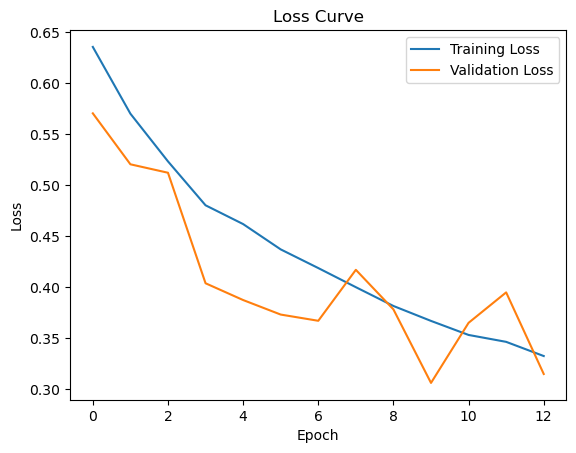

In [26]:
# Plotting Training vs Validation Loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

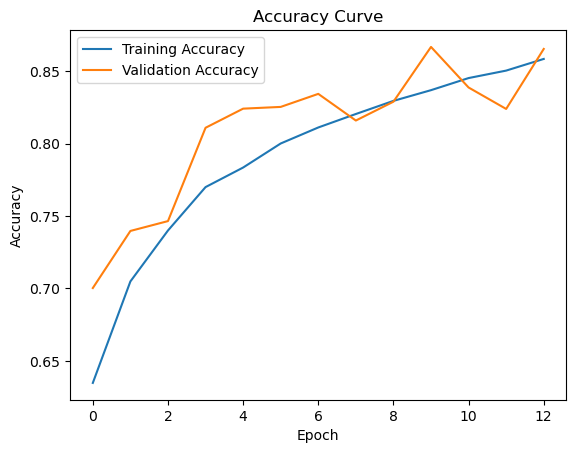

In [27]:
# Plotting Training vs Validation Accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Step 4: Visualize predictions with matplotlib

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


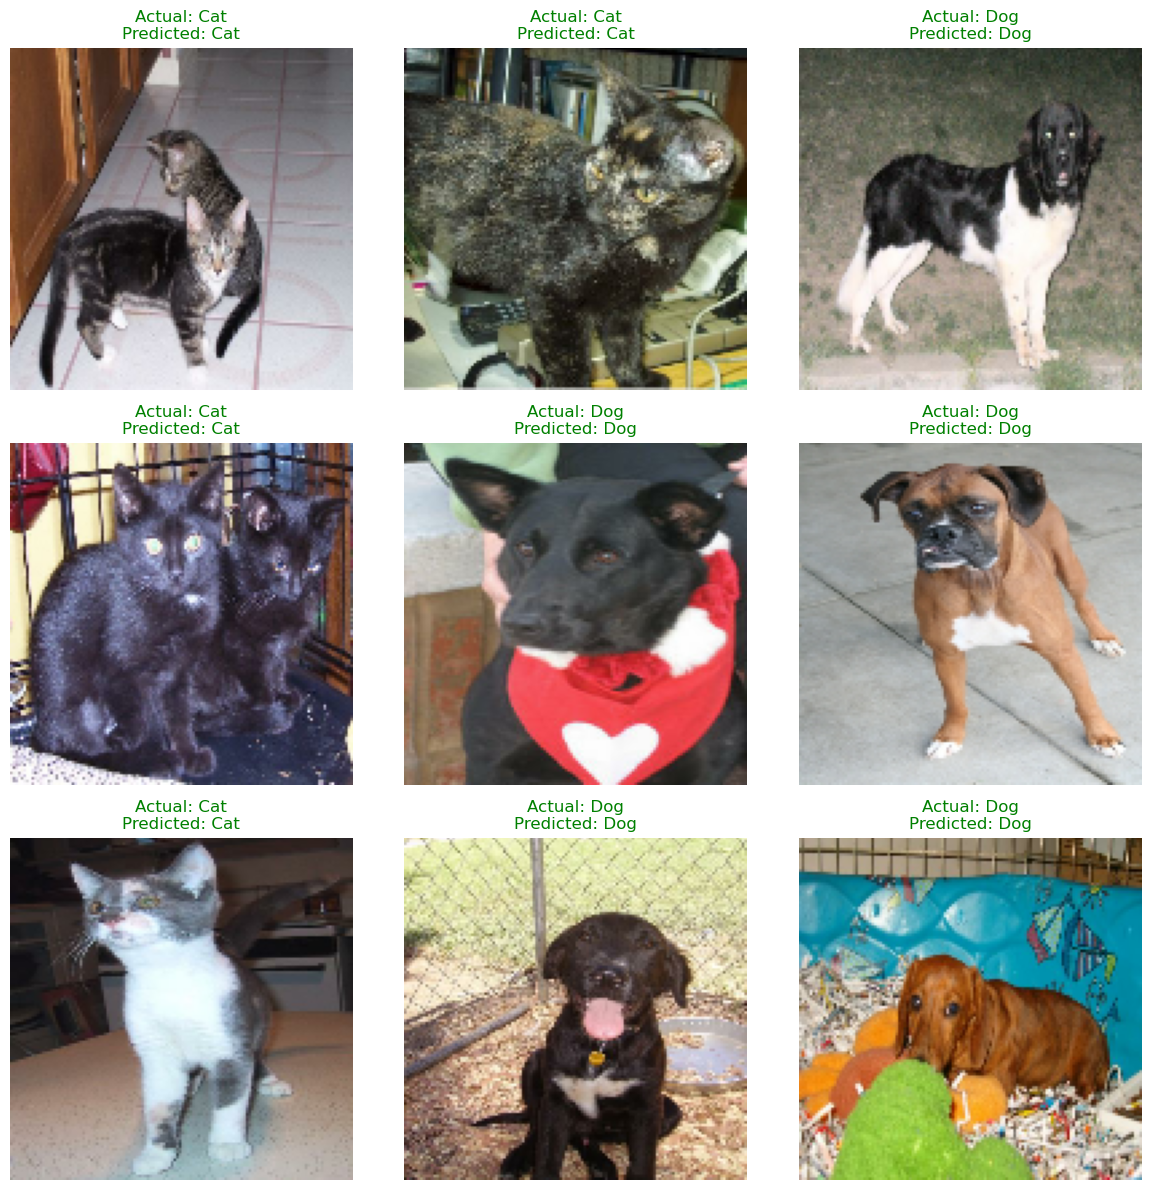

In [28]:
class_names = ["Cat", "Dog"]  # alphabetical folder order — matches how image_dataset_from_directory assigned labels

plt.figure(figsize=(12, 12))
for images, labels in val_ds.take(1):          # grab one batch (32 images) from val_ds
    predictions = model.predict(images)
    predicted_labels = (predictions > 0.5).astype("int32").flatten()  # sigmoid output -> 0/1

    for i in range(9):                          # show the first 9 images in the batch
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        actual = class_names[int(labels[i])]
        predicted = class_names[predicted_labels[i]]
        color = "green" if actual == predicted else "red"
        plt.title(f"Actual: {actual}\nPredicted: {predicted}", color=color)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
# Predict new image
def predict_image(img_path, model, class_names=["Cat", "Dog"]):
    # 1. Load and resize to match training input shape (128x128, RGB)
    img = tf.keras.utils.load_img(img_path, target_size=(128, 128))
    img_array = tf.keras.utils.img_to_array(img)      # shape: (128, 128, 3)

    # 2. Normalize
    img_array = img_array / 255.0

    # 3. Add batch dimension — model expects (batch, 128, 128, 3), not a single image
    img_array = tf.expand_dims(img_array, axis=0)

    # 4. Predict
    prediction = model.predict(img_array, verbose=0)
    prob_dog = float(prediction[0][0])                # sigmoid output = P(Dog)
    predicted_class = class_names[int(prob_dog > 0.5)]
    confidence = prob_dog if predicted_class == "Dog" else 1 - prob_dog

    # 5. Show result
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.1%} confidence)")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence

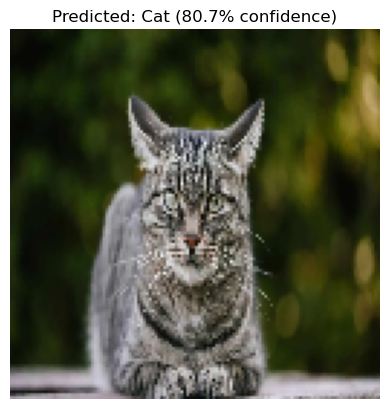

('Cat', 0.8066407144069672)

In [30]:
predict_image(r"C:\Users\Ahmed Tareq\Downloads\cat-test.webp", model)

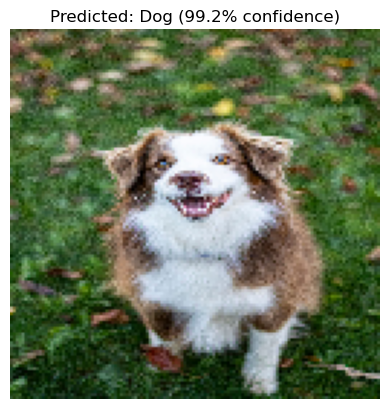

('Dog', 0.9924134612083435)

In [31]:
predict_image(r"C:\Users\Ahmed Tareq\Downloads\dog-test.jpg", model)

### Insights and Findings

**Overfitting was the central challenge, not model capacity:** The initial CNN reached 82.3% validation accuracy, but training accuracy climbed to 98.7% while validation loss more than doubled (0.40 → 0.91) over the same epochs — a clear sign the model was memorizing training images rather than learning generalizable features. This mattered more than the headline accuracy number itself: a high-accuracy-but-overfit model is less trustworthy than a slightly-lower-accuracy model that generalizes.

**Regularization improved both accuracy and reliability simultaneously:** Adding data augmentation (random flips, rotation, zoom), Dropout, and early stopping didn't just fix the overfitting — it also *raised* validation accuracy, from 82.3% to 86.7%. This is a useful, generalizable lesson: regularization is often framed as a trade-off ("sacrifice some accuracy for better generalization"), but here it improved both at once, because the original model's higher training accuracy was never real signal to begin with.

**Model confidence became more calibrated after fixing overfitting:** On a real downloaded cat photo, the original overfit model was 99.999% confident — an artificially inflated number driven by memorization rather than genuine certainty. The regularized model predicted the same image correctly but at 80.7% confidence, a more honest reflection of the model's actual certainty. This is a good practical reminder: extremely high confidence scores from a model are not automatically a good sign — they can indicate overfitting rather than genuine reliability.

**Early stopping identified a better model than manual epoch selection would have:** The best validation loss occurred at epoch 10 of a fixed-at-20 training run; without early stopping, a manually-chosen fixed epoch count could easily have kept training past this point (as the original 10-epoch run did) or stopped too early. Automating this decision with `EarlyStopping(monitor='val_loss', restore_best_weights=True)` removed the guesswork.

**Real-world testing beyond the held-out set matters:** Both manual predictions on freshly downloaded photos (not part of the original dataset) were classified correctly — one cat, one dog — providing a lightweight but meaningful sanity check that the model's learned features generalize beyond the specific images it was validated on, not just the metrics reported during training.

**Limitations worth noting for future iterations:**
- The validation set doubled as both the early-stopping monitor and the final "test" evaluation — a truly untouched third holdout set would make the 86.7% figure more rigorous.
- No pretrained backbone (e.g., MobileNetV2 via transfer learning) was used; a fine-tuned pretrained model would likely push accuracy meaningfully higher with less training time, given the dataset size (~25,000 images) is moderate rather than large.
- Evaluation relied on accuracy and loss alone — a confusion matrix would clarify whether errors skew toward false positives in one class (e.g., cats misclassified as dogs) more than the other.